# Quiz Praktikum — Logistic Regression
## Prediksi Tingkat Stress Mahasiswa

**Studi Kasus:** Prediksi tingkat stress mahasiswa berdasarkan pola tugas dan jam tidur menggunakan Logistic Regression.

**Klasifikasi:**
- `0` = Tidak Stress
- `1` = Stress

---
## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 1. Membaca Dataset

In [2]:
# Membaca dataset survei kelas
df = pd.read_csv('dataset.csv')

print('=== INFO DATASET ===')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')
print()
print('=== KOLOM ===')
print(df.columns.tolist())
print()
print('=== 5 DATA PERTAMA ===')
df.head()

=== INFO DATASET ===
Jumlah baris : 42
Jumlah kolom : 8

=== KOLOM ===
['Timestamp', 'Nama Lengkap', 'NIM', 'jumlah tugas', 'jumlah deadline', 'rata rata jam tidur', 'Stress?', 'Stress']

=== 5 DATA PERTAMA ===


,Timestamp,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress?,Stress
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1


In [3]:
# Tipe data setiap kolom
print('=== TIPE DATA ===')
print(df.dtypes)

=== TIPE DATA ===
Timestamp              object
Nama Lengkap           object
NIM                     int64
jumlah tugas            int64
jumlah deadline         int64
rata rata jam tidur     int64
Stress?                object
Stress                  int64
dtype: object


---
## 2. Data Cleaning

In [4]:
print('=== CEK MISSING VALUE (SEBELUM CLEANING) ===')
print(df.isnull().sum())
print(f'\nTotal missing value: {df.isnull().sum().sum()}')

=== CEK MISSING VALUE (SEBELUM CLEANING) ===
Timestamp              5
Nama Lengkap           0
NIM                    0
jumlah tugas           0
jumlah deadline        0
rata rata jam tidur    0
Stress?                0
Stress                 0
dtype: int64

Total missing value: 5


In [5]:
# Hapus baris yang memiliki missing value
df_clean = df.dropna()
print(f'Baris sebelum drop NA : {len(df)}')
print(f'Baris setelah drop NA : {len(df_clean)}')

Baris sebelum drop NA : 42
Baris setelah drop NA : 37


In [6]:
# Hapus data duplikat
jumlah_duplikat = df_clean.duplicated().sum()
print(f'Jumlah data duplikat: {jumlah_duplikat}')

df_clean = df_clean.drop_duplicates()
print(f'Baris setelah hapus duplikat: {len(df_clean)}')

Jumlah data duplikat: 0
Baris setelah hapus duplikat: 37


In [7]:
# Pastikan kolom numerik bertipe int/float
kolom_numerik = ['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur', 'Stress']
for col in kolom_numerik:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop sisa NaN jika konversi gagal
df_clean = df_clean.dropna(subset=kolom_numerik)

print('=== TIPE DATA SETELAH CLEANING ===')
print(df_clean[kolom_numerik].dtypes)

=== TIPE DATA SETELAH CLEANING ===
jumlah tugas           int64
jumlah deadline        int64
rata rata jam tidur    int64
Stress                 int64
dtype: object


In [8]:
# Verifikasi label Stress sudah 0 dan 1
print('=== DISTRIBUSI LABEL STRESS ===')
print(df_clean['Stress'].value_counts())
print()
print('Mapping: 0 = Tidak Stress | 1 = Stress')

=== DISTRIBUSI LABEL STRESS ===
Stress
1    20
0    17
Name: count, dtype: int64

Mapping: 0 = Tidak Stress | 1 = Stress


In [9]:
# Tampilkan dataset hasil cleaning
print(f'=== DATASET BERSIH: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom ===')
df_clean[['Nama Lengkap', 'NIM', 'jumlah tugas', 'jumlah deadline', 'rata rata jam tidur', 'Stress']].head(10)

=== DATASET BERSIH: 37 baris, 8 kolom ===


,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress
0,Muhammad Rayhan Mumtaz,2024081040,5,5,7,1
1,Elpam Jovi Anata,2025081046,2,1,10,0
2,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,0
3,Aura Keyfas Brilea,2025011015,4,2,6,0
4,Nabila Dwi Novianti,2025011017,5,1,5,1
5,Icha Marisa Mahmuda,2024081054,2,0,6,0
6,Panji Kurnia Akbar,2024081024,4,1,5,1
7,Raden Najla Ramadhani,2024081055,4,2,6,1
8,Masagus Rakhalish Zhafran Pratama,2024081020,3,1,5,0
9,Rheina Dwi Amalia Gotama,2025081045,7,0,7,0


---
## 3. Feature Selection

In [10]:
# Fitur (X) dan target/label (y)
X = df_clean[['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur']]
y = df_clean['Stress']

print('=== FITUR (X) ===')
print(X.describe())
print()
print('=== TARGET (y) ===')
print(y.value_counts())
print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')

=== FITUR (X) ===
       jumlah tugas  jumlah deadline  rata rata jam tidur
count     37.000000        37.000000            37.000000
mean       3.675676         1.702703             5.864865
std        2.000751         1.543173             1.417395
min        0.000000         0.000000             3.000000
25%        3.000000         1.000000             5.000000
50%        4.000000         1.000000             6.000000
75%        5.000000         2.000000             7.000000
max       10.000000         6.000000            10.000000

=== TARGET (y) ===
Stress
1    20
0    17
Name: count, dtype: int64

Shape X: (37, 3)
Shape y: (37,)


---
## 4. Split Data (Training & Testing)

In [11]:
# Bagi dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # jaga proporsi kelas
)

print('=== SPLIT DATA ===')
print(f'Total data        : {len(X)}')
print(f'Data training (80%): {len(X_train)}')
print(f'Data testing  (20%): {len(X_test)}')
print()
print('Distribusi label training:')
print(y_train.value_counts())
print()
print('Distribusi label testing:')
print(y_test.value_counts())

=== SPLIT DATA ===
Total data        : 37
Data training (80%): 29
Data testing  (20%): 8

Distribusi label training:
Stress
1    16
0    13
Name: count, dtype: int64

Distribusi label testing:
Stress
1    4
0    4
Name: count, dtype: int64


---
## 5. Training Model

In [12]:
# Inisialisasi dan latih model Logistic Regression
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print('=== MODEL BERHASIL DILATIH ===')
print(f'Intercept (b0): {model.intercept_[0]:.4f}')
print()
print('Koefisien fitur:')
for fitur, koef in zip(X.columns, model.coef_[0]):
    print(f'  {fitur:30s}: {koef:.4f}')

=== MODEL BERHASIL DILATIH ===
Intercept (b0): 1.0749

Koefisien fitur:
  jumlah tugas                  : 0.3009
  jumlah deadline               : 0.2113
  rata rata jam tidur           : -0.3896


---
## 6. Prediction

In [13]:
# Prediksi pada data testing
y_pred = model.predict(X_test)

print('=== HASIL PREDIKSI vs AKTUAL ===')
hasil_prediksi = pd.DataFrame({
    'Aktual'   : y_test.values,
    'Prediksi' : y_pred,
    'Benar?'   : y_test.values == y_pred
})
print(hasil_prediksi.to_string(index=False))

=== HASIL PREDIKSI vs AKTUAL ===
 Aktual  Prediksi  Benar?
      1         1    True
      1         1    True
      0         1   False
      0         0    True
      0         0    True
      1         1    True
      0         0    True
      1         1    True


---
## 7. Evaluation

In [14]:
# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f'=== AKURASI MODEL ===')
print(f'Akurasi: {akurasi:.4f} ({akurasi*100:.2f}%)')

=== AKURASI MODEL ===
Akurasi: 0.8750 (87.50%)


In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('=== CONFUSION MATRIX ===')
print(cm)
print()
print('Keterangan:')
print(f'  True Negative  (TN) — Prediksi Tidak Stress, Aktual Tidak Stress : {cm[0][0]}')
print(f'  False Positive (FP) — Prediksi Stress, Aktual Tidak Stress       : {cm[0][1]}')
print(f'  False Negative (FN) — Prediksi Tidak Stress, Aktual Stress       : {cm[1][0]}')
print(f'  True Positive  (TP) — Prediksi Stress, Aktual Stress             : {cm[1][1]}')

=== CONFUSION MATRIX ===
[[3 1]
 [0 4]]

Keterangan:
  True Negative  (TN) — Prediksi Tidak Stress, Aktual Tidak Stress : 3
  False Positive (FP) — Prediksi Stress, Aktual Tidak Stress       : 1
  False Negative (FN) — Prediksi Tidak Stress, Aktual Stress       : 0
  True Positive  (TP) — Prediksi Stress, Aktual Stress             : 4


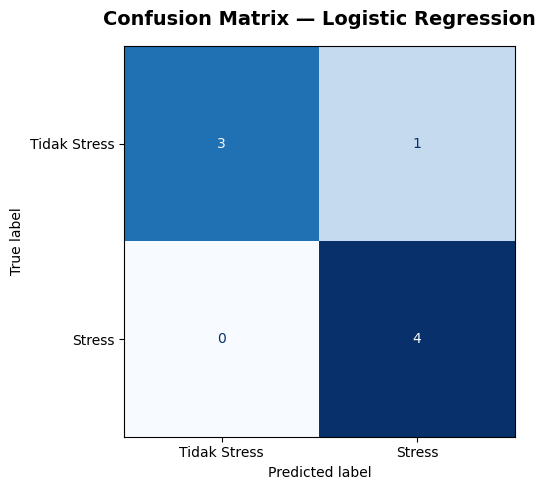

In [16]:
# Visualisasi Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Stress', 'Stress'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [17]:
# Classification Report
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Tidak Stress', 'Stress']))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Tidak Stress       1.00      0.75      0.86         4
      Stress       0.80      1.00      0.89         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



---
## 8. Probabilitas Prediksi

In [18]:
# Probabilitas prediksi menggunakan predict_proba()
y_proba = model.predict_proba(X_test)

print('=== PROBABILITAS PREDIKSI ===')
print(f'{"No":<5} {"Tidak Stress":>15} {"Stress":>10} {"Prediksi":>12} {"Aktual":>10}')
print('-' * 58)
for i, (prob, pred, aktual) in enumerate(zip(y_proba, y_pred, y_test.values)):
    label_pred = 'Stress' if pred == 1 else 'Tidak Stress'
    label_aktual = 'Stress' if aktual == 1 else 'Tidak Stress'
    print(f'{i+1:<5} {prob[0]*100:>13.1f}% {prob[1]*100:>8.1f}%  {label_pred:>12}  {label_aktual:>10}')

=== PROBABILITAS PREDIKSI ===
No       Tidak Stress     Stress     Prediksi     Aktual
----------------------------------------------------------
1              38.9%     61.1%        Stress      Stress
2              30.1%     69.9%        Stress      Stress
3              34.0%     66.0%        Stress  Tidak Stress
4              58.9%     41.1%  Tidak Stress  Tidak Stress
5              63.1%     36.9%  Tidak Stress  Tidak Stress
6               7.2%     92.8%        Stress      Stress
7              65.9%     34.1%  Tidak Stress  Tidak Stress
8              34.0%     66.0%        Stress      Stress


In [19]:
# Contoh interpretasi probabilitas untuk 1 mahasiswa
contoh_idx = 0
prob_tidak_stress = y_proba[contoh_idx][0]
prob_stress       = y_proba[contoh_idx][1]

print(f'=== CONTOH INTERPRETASI PROBABILITAS (Data ke-{contoh_idx+1}) ===')
print(f'Probabilitas Tidak Stress : {prob_tidak_stress*100:.1f}%')
print(f'Probabilitas Stress       : {prob_stress*100:.1f}%')
print()
if prob_stress > prob_tidak_stress:
    print(f'=> Mahasiswa ini DIPREDIKSI STRESS dengan keyakinan {prob_stress*100:.1f}%')
else:
    print(f'=> Mahasiswa ini DIPREDIKSI TIDAK STRESS dengan keyakinan {prob_tidak_stress*100:.1f}%')

=== CONTOH INTERPRETASI PROBABILITAS (Data ke-1) ===
Probabilitas Tidak Stress : 38.9%
Probabilitas Stress       : 61.1%

=> Mahasiswa ini DIPREDIKSI STRESS dengan keyakinan 61.1%


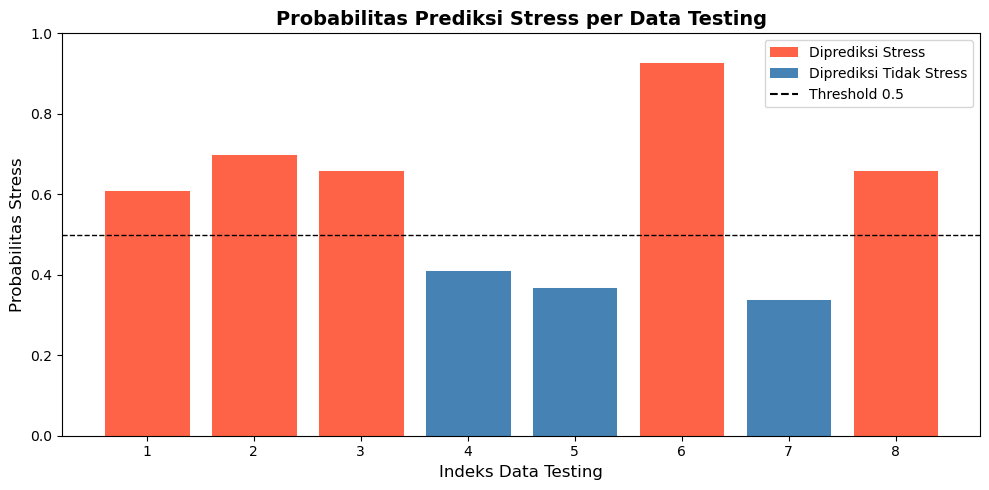

In [20]:
# Visualisasi probabilitas prediksi untuk semua data testing
indices = range(1, len(y_proba) + 1)
prob_stress_list = y_proba[:, 1]

warna = ['tomato' if p >= 0.5 else 'steelblue' for p in prob_stress_list]

plt.figure(figsize=(10, 5))
bars = plt.bar(indices, prob_stress_list, color=warna, edgecolor='white', linewidth=0.7)
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1, label='Threshold (0.5)')
plt.xlabel('Indeks Data Testing', fontsize=12)
plt.ylabel('Probabilitas Stress', fontsize=12)
plt.title('Probabilitas Prediksi Stress per Data Testing', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(indices)
plt.legend()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato', label='Diprediksi Stress'),
    Patch(facecolor='steelblue', label='Diprediksi Tidak Stress'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Threshold 0.5')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

---
## 9. Analisis

### 1. Mengapa Logistic Regression cocok untuk kasus ini?

Logistic Regression cocok karena kasus prediksi stress mahasiswa merupakan **masalah klasifikasi biner** (hanya dua kelas: Stress atau Tidak Stress). Logistic Regression dirancang khusus untuk mengklasifikasikan output ke dalam dua kategori dengan menggunakan fungsi sigmoid yang mengubah nilai linear menjadi probabilitas antara 0 dan 1. Selain itu, model ini mudah diinterpretasi karena koefisien setiap fitur menunjukkan seberapa besar pengaruhnya terhadap kemungkinan stress.

### 2. Mengapa probabilitas penting dalam prediksi stress?

Probabilitas memberikan informasi lebih kaya dibandingkan hanya label prediksi (0/1). Misalnya, prediksi "Stress" dengan probabilitas 95% jauh lebih pasti dibanding probabilitas 52%. Dalam konteks kesehatan mental mahasiswa, probabilitas membantu pihak kampus atau konselor untuk **memprioritaskan intervensi** — mahasiswa dengan probabilitas stress tinggi perlu mendapat perhatian lebih segera dibanding yang borderline.

### 3. Faktor apa yang paling memengaruhi stress mahasiswa?

Berdasarkan koefisien model di atas:
- **Jumlah tugas melewati deadline** memiliki koefisien positif terbesar → paling berkontribusi terhadap stress
- **Jumlah tugas** juga berkontribusi positif → semakin banyak tugas, semakin besar risiko stress
- **Rata-rata jam tidur** memiliki koefisien negatif → semakin banyak tidur, semakin kecil kemungkinan stress

### 4. Apa kelemahan model yang dibuat?

- **Dataset kecil** — hanya 42 data survei, sehingga model belum cukup generalisasi
- **Fitur terbatas** — faktor lain seperti kondisi keuangan, lingkungan sosial, dan beban kerja tidak dimasukkan
- **Self-report bias** — data didapat dari survei, sehingga responden mungkin tidak melaporkan kondisi sesungguhnya
- **Logistic Regression linier** — tidak dapat menangkap hubungan non-linear antar fitur jika ada
- **Data tidak seimbang sempurna** — meskipun sudah hampir seimbang (22 stress vs 20 tidak stress), tetap perlu diwaspadai

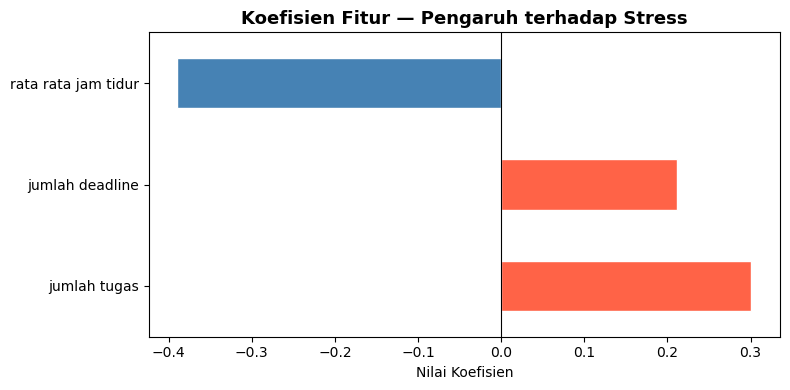

Merah  = meningkatkan risiko stress
Biru   = mengurangi risiko stress


In [21]:
# Visualisasi koefisien fitur (pengaruh terhadap stress)
koefisien = pd.Series(model.coef_[0], index=X.columns)
warna_koef = ['tomato' if k > 0 else 'steelblue' for k in koefisien]

plt.figure(figsize=(8, 4))
koefisien.plot(kind='barh', color=warna_koef, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Koefisien Fitur — Pengaruh terhadap Stress', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()
print('Merah  = meningkatkan risiko stress')
print('Biru   = mengurangi risiko stress')

---
## Ringkasan Hasil

In [22]:
print('=' * 50)
print('       RINGKASAN HASIL PRAKTIKUM')
print('=' * 50)
print(f'Total data setelah cleaning : {len(df_clean)}')
print(f'Data training               : {len(X_train)}')
print(f'Data testing                : {len(X_test)}')
print(f'Akurasi model               : {akurasi*100:.2f}%')
print()
print('Confusion Matrix:')
print(f'  TN={cm[0][0]}  FP={cm[0][1]}')
print(f'  FN={cm[1][0]}  TP={cm[1][1]}')
print()
print('Fitur yang digunakan:')
print('  - jumlah tugas')
print('  - jumlah deadline')
print('  - rata rata jam tidur')
print()
print('Target: Stress (0 = Tidak Stress, 1 = Stress)')
print('=' * 50)

       RINGKASAN HASIL PRAKTIKUM
Total data setelah cleaning : 37
Data training               : 29
Data testing                : 8
Akurasi model               : 87.50%

Confusion Matrix:
  TN=3  FP=1
  FN=0  TP=4

Fitur yang digunakan:
  - jumlah tugas
  - jumlah deadline
  - rata rata jam tidur

Target: Stress (0 = Tidak Stress, 1 = Stress)
